# Home task: clustering(Kmeans)

## Import libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification

## Generate data


X shape: (200, 3)


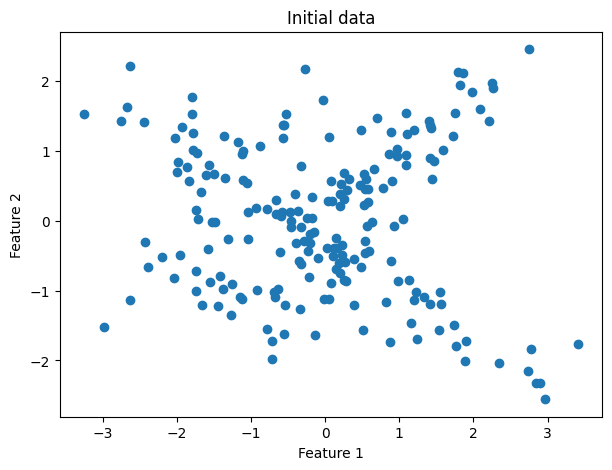

In [2]:
# generate dataset
Xc_2, _ = make_classification(
    n_samples=200,
    n_features=3,
    n_informative=2,
    n_redundant=1,
    random_state=3,
    n_clusters_per_class=2,
    class_sep=0.8
)

print("X shape:", Xc_2.shape)

plt.figure(figsize=(7, 5))
plt.scatter(Xc_2[:, 0], Xc_2[:, 1])
plt.title("Initial data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Initialize centroids


In [3]:
def init_centroids(X, K):
    # choose K random unique points as initial centroids
    random_ids = np.random.choice(X.shape[0], size=K, replace=False)
    centroids = X[random_ids]
    return centroids

## Compute distances


In [4]:
def compute_distances(X, centroids):
    # distances shape: (number of samples, number of centroids)
    distances = np.sqrt(((X[:, np.newaxis, :] - centroids[np.newaxis, :, :]) ** 2).sum(axis=2))
    return distances

## Assign points to closest centroid


In [5]:
def assign_clusters(X, centroids):
    distances = compute_distances(X, centroids)
    cluster_ids = np.argmin(distances, axis=1)
    return cluster_ids

## Recompute centroids


In [6]:
def compute_centroids(X, cluster_ids, K):
    new_centroids = []
    
    for k in range(K):
        cluster_points = X[cluster_ids == k]
        
        # if cluster is empty, reinitialize centroid randomly
        if len(cluster_points) == 0:
            random_point = X[np.random.randint(0, X.shape[0])]
            new_centroids.append(random_point)
        else:
            new_centroids.append(cluster_points.mean(axis=0))
    
    return np.array(new_centroids)

## Compute cost


In [7]:
def compute_cost(X, centroids, cluster_ids):
    m = X.shape[0]
    cost = 0.0
    
    for i in range(m):
        centroid = centroids[cluster_ids[i]]
        cost += np.sum((X[i] - centroid) ** 2)
    
    return cost / m

## Run one K-means process


In [8]:
def run_kmeans(X, K=2, max_iters=100, tol=1e-4):
    centroids = init_centroids(X, K)
    cost_history = []
    
    for i in range(max_iters):
        # step 1: assign clusters
        cluster_ids = assign_clusters(X, centroids)
        
        # step 2: recompute centroids
        new_centroids = compute_centroids(X, cluster_ids, K)
        
        # step 3: compute cost
        cost = compute_cost(X, new_centroids, cluster_ids)
        cost_history.append(cost)
        
        # check convergence
        if i > 0 and abs(cost_history[-2] - cost_history[-1]) < tol:
            centroids = new_centroids
            break
        
        centroids = new_centroids
    
    return centroids, cluster_ids, cost_history

## Test one K-means run


In [9]:
np.random.seed(42)

K = 4
centroids, cluster_ids, cost_history = run_kmeans(Xc_2, K=K)

print("Final centroids:")
print(centroids)

print("Final cost:", cost_history[-1])
print("Number of iterations:", len(cost_history))

Final centroids:
[[ 1.80339351 -1.58275292 -0.48386019]
 [-1.58374346 -0.01181412  1.38094106]
 [ 0.03955954 -0.07201392  0.01482056]
 [ 1.34360373  1.37863324 -2.10493731]]
Final cost: 1.292803621775289
Number of iterations: 15


## Plot cost changes


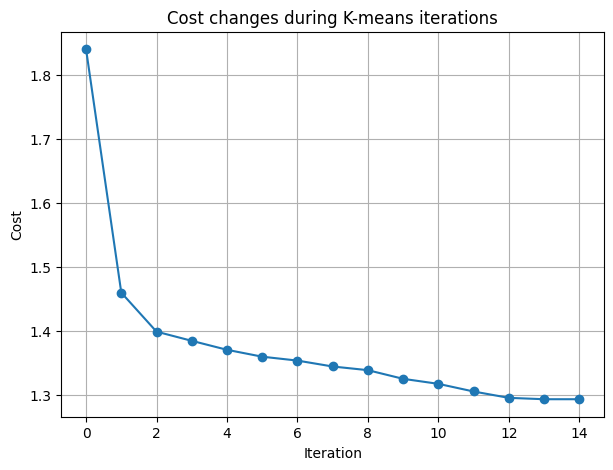

In [10]:
plt.figure(figsize=(7, 5))
plt.plot(cost_history, marker='o')
plt.title("Cost changes during K-means iterations")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

## Visualize clustering result for one run


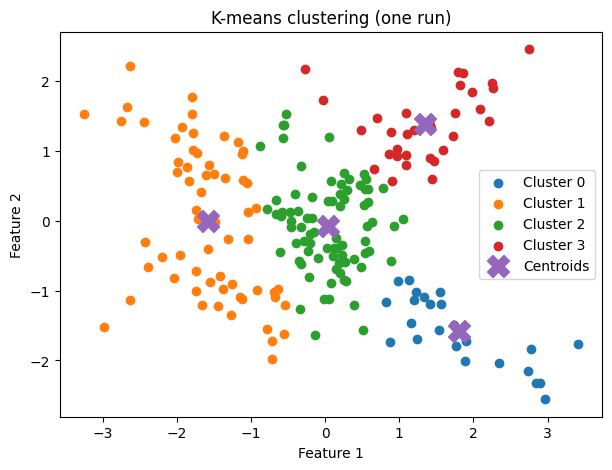

In [11]:
plt.figure(figsize=(7, 5))

for k in range(K):
    plt.scatter(
        Xc_2[cluster_ids == k, 0],
        Xc_2[cluster_ids == k, 1],
        label=f"Cluster {k}"
    )

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=250,
    label='Centroids'
)

plt.title("K-means clustering (one run)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

## Run K-means 100 times


In [13]:
def best_kmeans_of_n_runs(X, K=4, n_runs=100, max_iters=100, tol=1e-4):
    best_cost = np.inf
    best_centroids = None
    best_cluster_ids = None
    best_cost_history = None
    
    for run in range(n_runs):
        centroids, cluster_ids, cost_history = run_kmeans(X, K=K, max_iters=max_iters, tol=tol)
        final_cost = cost_history[-1]
        
        if final_cost < best_cost:
            best_cost = final_cost
            best_centroids = centroids.copy()
            best_cluster_ids = cluster_ids.copy()
            best_cost_history = cost_history.copy()
    
    return best_centroids, best_cluster_ids, best_cost_history, best_cost

## Get the best clustering


In [14]:
np.random.seed(42)

best_centroids, best_cluster_ids, best_cost_history, best_cost = best_kmeans_of_n_runs(
    Xc_2,
    K=2,
    n_runs=100
)

print("Best cost:", best_cost)
print("Best centroids:")
print(best_centroids)

Best cost: 2.59867626221071
Best centroids:
[[ 1.15203602  0.1723529  -1.11619778]
 [-0.96652957 -0.12381663  0.92228816]]


## Final visualization


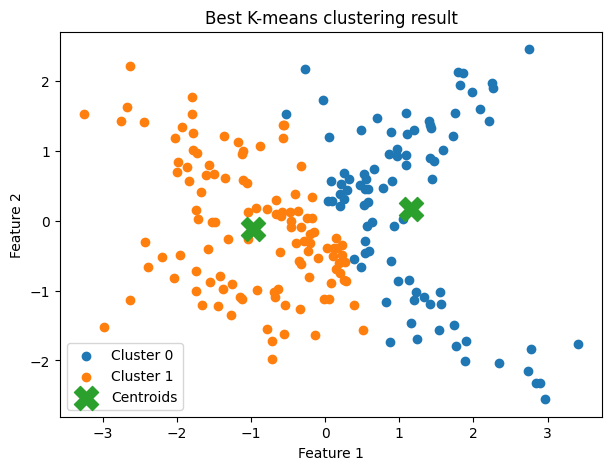

In [15]:
plt.figure(figsize=(7, 5))

for k in range(2):
    plt.scatter(
        Xc_2[best_cluster_ids == k, 0],
        Xc_2[best_cluster_ids == k, 1],
        label=f"Cluster {k}"
    )

plt.scatter(
    best_centroids[:, 0],
    best_centroids[:, 1],
    marker='X',
    s=300,
    label='Centroids'
)

plt.title("Best K-means clustering result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

## Cost changes for the best run


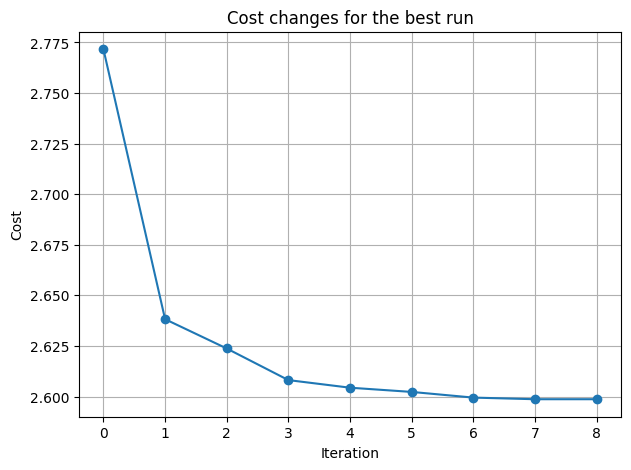

In [16]:
plt.figure(figsize=(7, 5))
plt.plot(best_cost_history, marker='o')
plt.title("Cost changes for the best run")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

## Elbow method (optional)


In [17]:
# try different K values and store cost
K_values = range(1, 10)
costs = []

for K in K_values:
    _, _, _, best_cost = best_kmeans_of_n_runs(Xc_2, K=K, n_runs=20)
    costs.append(best_cost)

## Elbow Method Visualization

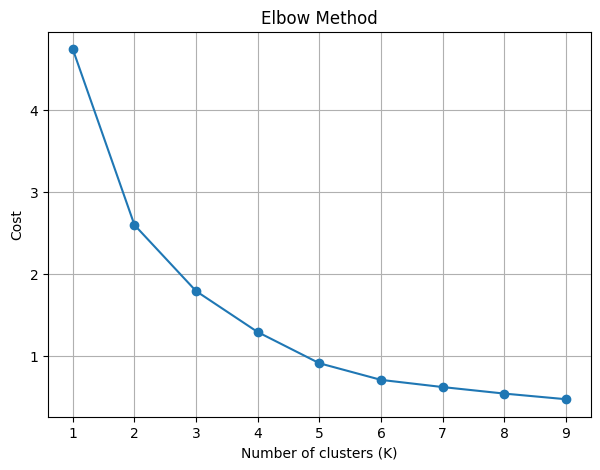

In [18]:
plt.figure(figsize=(7, 5))
plt.plot(K_values, costs, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Cost")
plt.grid(True)

plt.show()